In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [50]:
file_path = '/content/drive/MyDrive/S8338.xlsx'
try:
    df_drive = pd.read_excel(file_path)
except Exception as e:
    print(f"An error occurred while loading the file: {e}")
df_drive.head()

,S8338,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,NaN,pdb_chains,num_chain,biounit_chain,chain.mut,hgroup_folds,ddG,DGCddG,TopNetTree
1,0.0,1E50_ABCDEFGHQR,2,AB,A.D66A,1,402,-1.96082746982574,0.934977302319
2,1.0,1E50_ABCDEFGHQR,2,AB,A.K144M,1,-0.32,-0.943346619606018,1.00838132699
3,2.0,1E50_ABCDEFGHQR,2,AB,A.M106A,1,-1.32,-1.78484702110291,1.03050875539
4,3.0,1E50_ABCDEFGHQR,2,AB,A.N69A,1,-678,-0.603846609592438,0.745495683194


In [51]:
df_drive = df_drive.drop(columns=['S8338'])

# Set the first row (index 0) as the new column headers.
df_drive.columns = df_drive.iloc[0]

# Drop the now-redundant first row from the DataFrame and reset the index.
df_drive = df_drive[1:].reset_index(drop=True)

# Rename the 'pdb_chains' column to 'Skempi' as requested.
df_drive = df_drive.rename(columns={'pdb_chains': 'Skempi'})

# Display the first few rows of the cleaned DataFrame to confirm the changes.
df_drive.head()

,Skempi,num_chain,biounit_chain,chain.mut,hgroup_folds,ddG,DGCddG,TopNetTree
0,1E50_ABCDEFGHQR,2,AB,A.D66A,1,402,-1.96082746982574,0.934977302319
1,1E50_ABCDEFGHQR,2,AB,A.K144M,1,-0.32,-0.943346619606018,1.00838132699
2,1E50_ABCDEFGHQR,2,AB,A.M106A,1,-1.32,-1.78484702110291,1.03050875539
3,1E50_ABCDEFGHQR,2,AB,A.N69A,1,-678,-0.603846609592438,0.745495683194
4,1E50_ABCDEFGHQR,2,AB,A.N109A,1,-2433,-1.20300006866455,0.787271117608


In [52]:
ids = df_drive["Skempi"].to_list()
i = 0
for i in range(len(ids)):
  ids[i] = ids[i].split('_')[0]
df_drive['PDB'] = ids
df_drive.head()

,Skempi,num_chain,biounit_chain,chain.mut,hgroup_folds,ddG,DGCddG,TopNetTree,PDB
0,1E50_ABCDEFGHQR,2,AB,A.D66A,1,402,-1.96082746982574,0.934977302319,1E50
1,1E50_ABCDEFGHQR,2,AB,A.K144M,1,-0.32,-0.943346619606018,1.00838132699,1E50
2,1E50_ABCDEFGHQR,2,AB,A.M106A,1,-1.32,-1.78484702110291,1.03050875539,1E50
3,1E50_ABCDEFGHQR,2,AB,A.N69A,1,-678,-0.603846609592438,0.745495683194,1E50
4,1E50_ABCDEFGHQR,2,AB,A.N109A,1,-2433,-1.20300006866455,0.787271117608,1E50


In [53]:
pdb_occurrences = df_drive['PDB'].value_counts().to_dict()
print(pdb_occurrences)
print(len(pdb_occurrences))

{'3BT1': 480, '3SGB': 382, '1CHO': 382, '1R0R': 382, '1PPF': 380, '1A22': 284, '1DAN': 178, '1AO7': 172, '3S9D': 162, '3HFM': 142, '1JTG': 116, '1GC1': 108, '1MHP': 100, '1OGA': 96, '1C4Z': 96, '1VFB': 96, '1EMV': 92, '1BP3': 90, '2JEL': 88, '1JRH': 86, '3NGB': 82, '1MI5': 78, '1LFD': 76, '4RS1': 72, '1IAR': 72, '1JTD': 72, '3C60': 70, '3BN9': 70, '4NKQ': 68, '1A4Y': 64, '1CBW': 62, '2FTL': 62, '4G0N': 60, '2NYY': 60, '1BRS': 60, '2WPT': 58, '2AK4': 58, '3SE8': 56, '2G2U': 54, '3NPS': 54, '1KTZ': 54, '3SE4': 54, '1EAW': 54, '4P23': 52, '2BNR': 52, '4P5T': 52, '4PWX': 50, '3SE9': 50, '1DVF': 50, '3QHY': 50, '3QIB': 50, '1DQJ': 42, '3SZK': 42, '1B41': 40, '1FSS': 40, '1K8R': 38, '2NZ9': 38, '1FFW': 38, '3M62': 36, '1XD3': 36, '1FC2': 36, '5C6T': 36, '1Z7X': 34, '3SE3': 34, '1TM1': 34, '1E50': 32, '1YY9': 32, '1AK4': 32, '2J0T': 32, '3QDJ': 30, '1C1Y': 30, '5M2O': 28, '3QDG': 28, '1KNE': 26, '5F4E': 26, '3BK3': 26, '1N8Z': 24, '4I77': 24, '1F47': 24, '4OZG': 24, '1GUA': 24, '2BDN': 24, '5

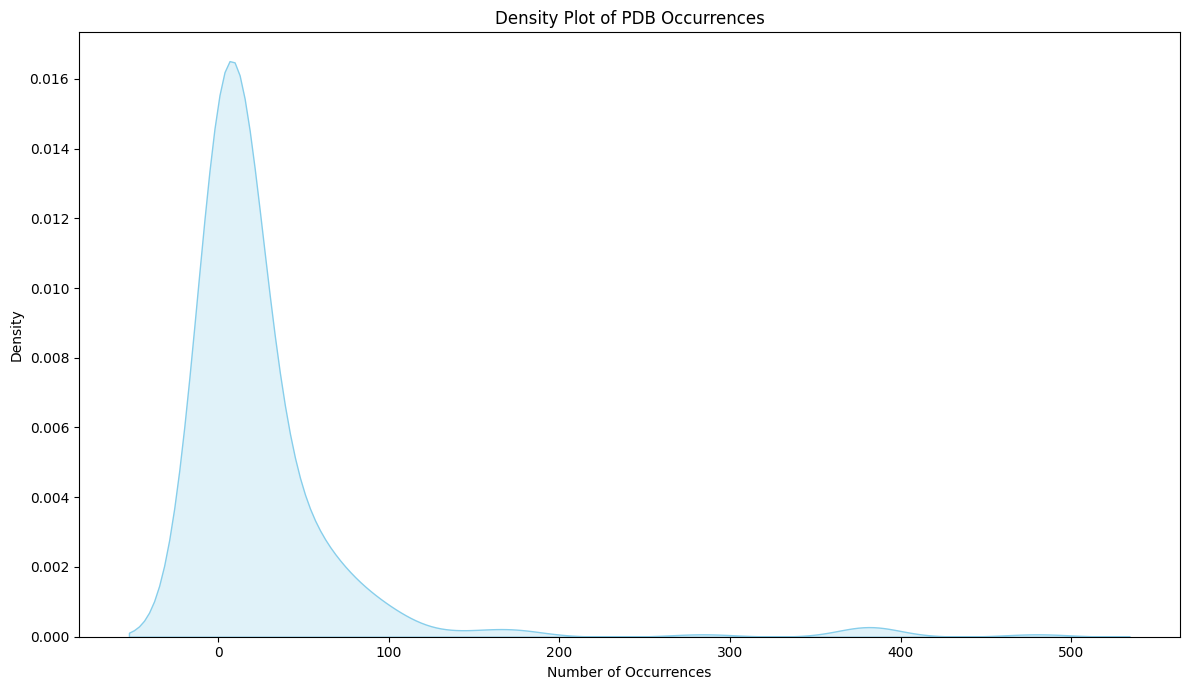

In [54]:
pdb_counts_series = pd.Series(pdb_occurrences)

plt.figure(figsize=(12, 7))
sns.kdeplot(pdb_counts_series.values, fill=True, color='skyblue')
plt.title('Density Plot of PDB Occurrences')
plt.xlabel('Number of Occurrences')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

In [55]:
for key in pdb_occurrences:
  print(key)

3BT1
3SGB
1CHO
1R0R
1PPF
1A22
1DAN
1AO7
3S9D
3HFM
1JTG
1GC1
1MHP
1OGA
1C4Z
1VFB
1EMV
1BP3
2JEL
1JRH
3NGB
1MI5
1LFD
4RS1
1IAR
1JTD
3C60
3BN9
4NKQ
1A4Y
1CBW
2FTL
4G0N
2NYY
1BRS
2WPT
2AK4
3SE8
2G2U
3NPS
1KTZ
3SE4
1EAW
4P23
2BNR
4P5T
4PWX
3SE9
1DVF
3QHY
3QIB
1DQJ
3SZK
1B41
1FSS
1K8R
2NZ9
1FFW
3M62
1XD3
1FC2
5C6T
1Z7X
3SE3
1TM1
1E50
1YY9
1AK4
2J0T
3QDJ
1C1Y
5M2O
3QDG
1KNE
5F4E
3BK3
1N8Z
4I77
1F47
4OZG
1GUA
2BDN
5XCO
3Q8D
3EQY
4OFY
4BFI
1MLC
3M63
3AAA
3MZG
2SIC
1JCK
3EQS
1BJ1
1MAH
1BD2
1AHW
4NM8
3N85
4B0M
4CPA
1FCC
5E9D
4JPK
4HFK
5TAR
1NMB
4CVW
5E6P
2O3B
4L3E
2AJF
2B0U
1GCQ
3SEK
3F1S
3HH2
3B4V
3BX1
4L0P
1E96
1ACB
4K71
4FTV
4JFF
4X4M
4JEU
3VR6
1H9D
1CSE
4YFD
3KBH
2PCC
2PCB
1S1Q
3SF4
3UIG
4J2L
3R9A
2KSO
1SMF
1UUZ
5K39
2DVW
5CXB
4YH7
5UFE
2DSQ
4N8V
4O27
2BTF
2C5D
1XGP
3D3V
1XGU
1XGT
1XGR
1XGQ
3LB6
1WQJ
3W2D
4HRN
4FZA
1NCA
4HSA
4YEB
2OOB
2AW2
4GNK
3WWN
1N8O
1KBH
1LP9
1SBB
3MZW
3KUD
2B2X
4NZW
2HRK
2J1K
2C0L
2B42
5UFQ
4E6K
2GOX
5CYK
1B2U
1B2S
4ZS6
1B3S
4GXU
4G2V
4RA0
1FY8
4Y61
4WND
4U6H
4KRO
4KRL


In [56]:
filepath = '/content/drive/MyDrive/ddmutppi.tsv'
try:
    df_mapping = pd.read_table(filepath)
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

In [57]:
df_mapping

,From,Entry,Entry Name
0,3BT1,P00749,UROK_HUMAN
1,3BT1,P04004,VTNC_HUMAN
2,3BT1,Q03405,UPAR_HUMAN
3,3SGB,P00777,PRTB_STRGR
4,3SGB,P68390,IOVO_MELGA
...,...,...,...
653,4KRP,P00533,EGFR_HUMAN
654,4LRX,P76015,DHAK_ECOLI
655,4LRX,P76016,DHAR_ECOLI
656,4MYW,P03172,GD_HHV23


In [58]:
from_entry_dict = df_mapping.groupby('From')['Entry'].apply(list).to_dict()
print(from_entry_dict)

{'1A22': ['P01241', 'P10912'], '1A4Y': ['P03950', 'P13489'], '1ACB': ['P01051', 'P00766'], '1AHW': ['P01837', 'P01868', 'P13726'], '1AK4': ['P12497', 'P62937'], '1AO7': ['P14079', 'A0A075B6T6', 'A0A0K0K1A5', 'A0A5B9', 'P01848', 'P01850', 'P04439', 'P61769'], '1B2S': ['P00648', 'P11540'], '1B2U': ['P00648', 'P11540'], '1B3S': ['P00648', 'P11540'], '1B41': ['P0C1Z0', 'P22303'], '1BD2': ['P14079', 'P0C213', 'A0A0K0K1A5', 'A0A5B9', 'P01848', 'P04437', 'P04439', 'P61769'], '1BJ1': ['P15692'], '1BP3': ['P01241', 'P16471'], '1BRS': ['P00648', 'P11540'], '1C1Y': ['P04049', 'P62834'], '1C4Z': ['P68036', 'Q05086'], '1CBW': ['P00766', 'P00767', 'P00974'], '1CHO': ['P68390', 'P00766'], '1CSE': ['P00780', 'P01051'], '1CSO': ['P00777', 'P68390'], '1CT0': ['P00777', 'P68390'], '1CT2': ['P00777', 'P68390'], '1CT4': ['P00777', 'P68390'], '1CZ8': ['P15692'], '1DAN': ['P08709', 'P13726'], '1DQJ': ['P01837', 'P01865', 'P00698'], '1DVF': ['P01635', 'P01646', 'P01820'], '1E50': ['Q01196', 'Q13951'], '1E96':

In [59]:
df_drive['uniprot'] = df_drive['PDB'].map(from_entry_dict)
display(df_drive.head())

,Skempi,num_chain,biounit_chain,chain.mut,hgroup_folds,ddG,DGCddG,TopNetTree,PDB,uniprot
0,1E50_ABCDEFGHQR,2,AB,A.D66A,1,402,-1.96082746982574,0.934977302319,1E50,"[Q01196, Q13951]"
1,1E50_ABCDEFGHQR,2,AB,A.K144M,1,-0.32,-0.943346619606018,1.00838132699,1E50,"[Q01196, Q13951]"
2,1E50_ABCDEFGHQR,2,AB,A.M106A,1,-1.32,-1.78484702110291,1.03050875539,1E50,"[Q01196, Q13951]"
3,1E50_ABCDEFGHQR,2,AB,A.N69A,1,-678,-0.603846609592438,0.745495683194,1E50,"[Q01196, Q13951]"
4,1E50_ABCDEFGHQR,2,AB,A.N109A,1,-2433,-1.20300006866455,0.787271117608,1E50,"[Q01196, Q13951]"


In [61]:
df_drive

,Skempi,num_chain,biounit_chain,chain.mut,hgroup_folds,ddG,DGCddG,TopNetTree,PDB,uniprot
0,1E50_ABCDEFGHQR,2,AB,A.D66A,1,402,-1.96082746982574,0.934977302319,1E50,"[Q01196, Q13951]"
1,1E50_ABCDEFGHQR,2,AB,A.K144M,1,-0.32,-0.943346619606018,1.00838132699,1E50,"[Q01196, Q13951]"
2,1E50_ABCDEFGHQR,2,AB,A.M106A,1,-1.32,-1.78484702110291,1.03050875539,1E50,"[Q01196, Q13951]"
3,1E50_ABCDEFGHQR,2,AB,A.N69A,1,-678,-0.603846609592438,0.745495683194,1E50,"[Q01196, Q13951]"
4,1E50_ABCDEFGHQR,2,AB,A.N109A,1,-2433,-1.20300006866455,0.787271117608,1E50,"[Q01196, Q13951]"
...,...,...,...,...,...,...,...,...,...,...
8333,5XCO_AB,2,AB,B.P6A,6,1079,1.65595602989197,2.5218398519,5XCO,[P01116]
8334,5XCO_AB,2,AB,B.S10A,6,1286,1.13375651836395,1.32200244887,5XCO,[P01116]
8335,5XCO_AB,2,AB,B.V14A,6,0,1.67255866527557,0.954171738684,5XCO,[P01116]
8336,5XCO_AB,2,AB,B.Y11A,6,1.9,2.51267075538635,0.0219471569657,5XCO,[P01116]


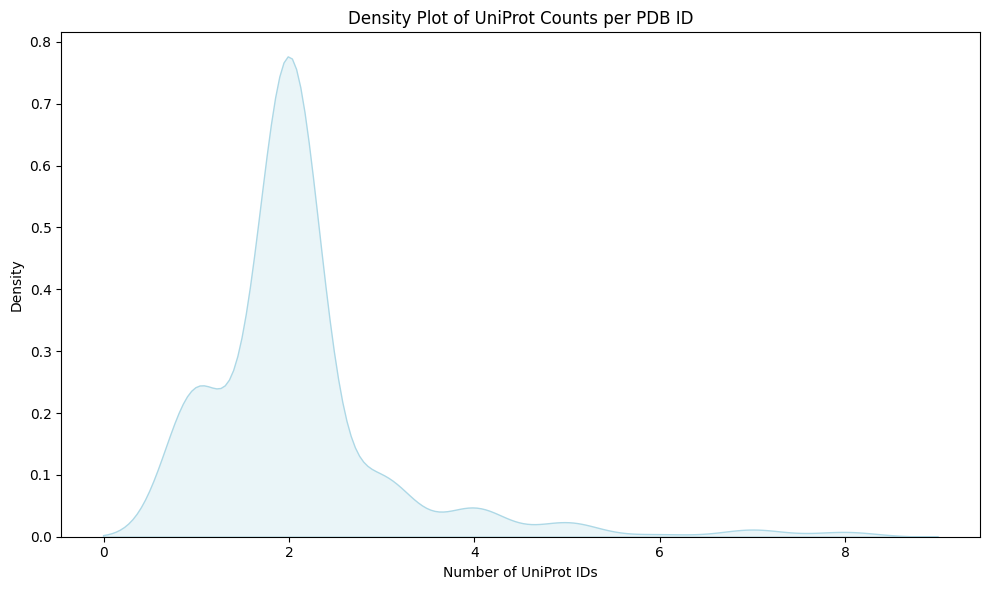

In [62]:
proteins_compl = {}
for key in from_entry_dict:
  proteins_compl[key]=len(from_entry_dict[key])

uniprot_counts_series = pd.Series(proteins_compl)

plt.figure(figsize=(10, 6))
sns.kdeplot(uniprot_counts_series.values, fill=True, color='lightblue')
plt.title('Density Plot of UniProt Counts per PDB ID')
plt.xlabel('Number of UniProt IDs')
plt.ylabel('Density')
plt.tight_layout()
plt.show()

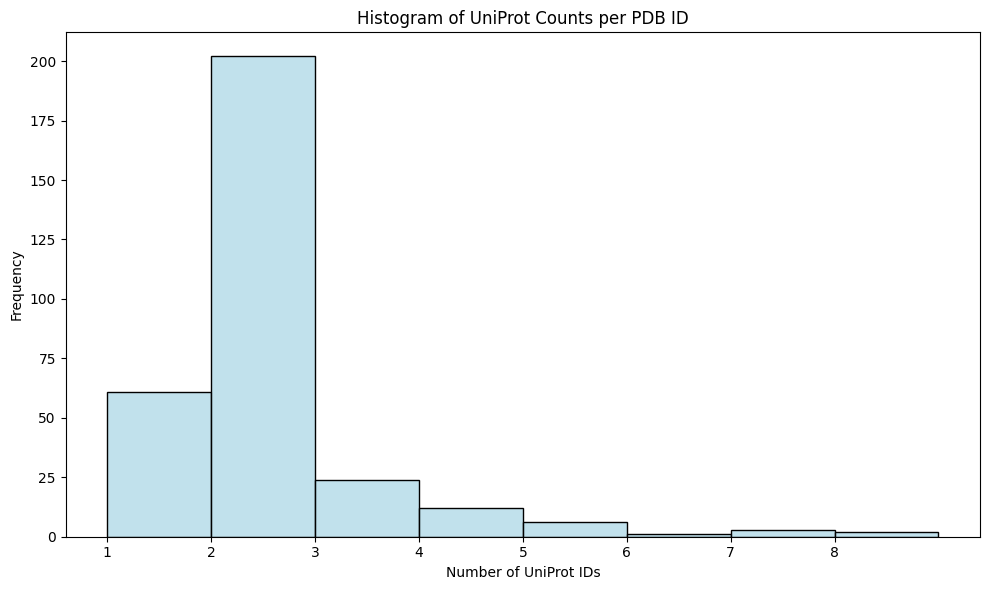

In [63]:
plt.figure(figsize=(10, 6))
sns.histplot(uniprot_counts_series.values, bins=range(1, max(uniprot_counts_series.values) + 2), kde=False, color='lightblue', edgecolor='black')
plt.title('Histogram of UniProt Counts per PDB ID')
plt.xlabel('Number of UniProt IDs')
plt.ylabel('Frequency')
plt.xticks(range(1, max(uniprot_counts_series.values) + 1))
plt.tight_layout()
plt.show()

In [64]:
min_uniprot_count = min(proteins_compl.values())
print(f"The minimum number of UniProt IDs associated with a PDB ID is: {min_uniprot_count}")

The minimum number of UniProt IDs associated with a PDB ID is: 1


In [65]:
max_uniprot_count = max(proteins_compl.values())
print(f"The maximum number of UniProt IDs associated with a PDB ID is: {max_uniprot_count}")

The maximum number of UniProt IDs associated with a PDB ID is: 8


In [66]:
prot_per_complex = {}

In [67]:
pdb_1_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 1]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_1_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_1_uniprot:
    print(pdb_id)
prot_per_complex[1]=len(pdb_1_uniprot)

Number of PDB IDs with exactly one UniProt ID: 61
PDB IDs with exactly one UniProt ID:
1BJ1
1CZ8
1JCK
1JTD
1M9E
1MHP
1N8Z
1NMB
1TM1
1TM3
1TM4
1TM5
1TM7
1TMG
1TO1
1XGR
1XGT
1Y1K
1Y33
1Y34
1Y3B
1Y3C
1Y3D
1Y48
1YQV
1YY9
2B42
2BDN
2E7L
2I26
2J12
2JEL
2NYY
2NZ9
2O3B
2VIR
2VIS
3BK3
3EQS
3EQY
3G6D
3L5X
3LNZ
3LZF
3N85
3NPS
3W2D
3WWN
4GXU
4HRN
4I77
4JPK
4KRL
4KRO
4KRP
4U6H
5C6T
5K39
5UFE
5UFQ
5XCO


In [68]:
pdb_2_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 2]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_2_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_2_uniprot:
    print(pdb_id)
prot_per_complex[2]=len(pdb_2_uniprot)

Number of PDB IDs with exactly one UniProt ID: 202
PDB IDs with exactly one UniProt ID:
1A22
1A4Y
1ACB
1AK4
1B2S
1B2U
1B3S
1B41
1BP3
1BRS
1C1Y
1C4Z
1CHO
1CSE
1CSO
1CT0
1CT2
1CT4
1DAN
1E50
1E96
1EAW
1EFN
1EMV
1F47
1F5R
1FC2
1FCC
1FFW
1FR2
1FSS
1FY8
1GC1
1GCQ
1GL0
1GL1
1GRN
1GUA
1H9D
1HE8
1IAR
1JTG
1K8R
1KAC
1KBH
1KIP
1KIQ
1KIR
1KNE
1KTZ
1LFD
1MAH
1N8O
1NCA
1P69
1P6A
1PPF
1QSE
1R0R
1REW
1S0W
1S1Q
1SBB
1SBN
1SGD
1SGE
1SGN
1SGP
1SGQ
1SGY
1SIB
1SMF
1U7F
1UUZ
1WQJ
1X1W
1X1X
1XD3
1XGP
1XGQ
1XGU
1YCS
1Z7X
2A9K
2AJF
2AW2
2B0U
2B0Z
2B10
2B11
2B12
2B2X
2BTF
2C0L
2C5D
2DVW
2FTL
2G2U
2G2W
2GOX
2GYK
2HLE
2HRK
2J0T
2J1K
2KSO
2NU0
2NU1
2NU2
2NU4
2OI9
2OOB
2PCB
2PCC
2REX
2SGP
2SGQ
2SIC
2VLN
2VLO
2VLP
2VLQ
2WPT
3B4V
3BP8
3BTD
3BTE
3BTF
3BTG
3BTH
3BTM
3BTQ
3BTT
3BTW
3BX1
3C60
3D5R
3D5S
3EG5
3F1S
3HFM
3HH2
3KBH
3KUD
3LB6
3M62
3M63
3MZG
3MZW
3N06
3N0P
3N4I
3NCB
3NCC
3NVN
3NVQ
3Q3J
3Q8D
3QFJ
3R9A
3RF3
3S9D
3SEK
3SF4
3SGB
3TGK
3U82
3UIG
3UII
4BFI
4CPA
4E6K
4EKD
4FZA
4G0N
4G2V
4GNK
4HSA
4J2L
4JEU
4L0P
4LRX
4M

In [69]:
pdb_3_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 3]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_3_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_3_uniprot:
    print(pdb_id)
prot_per_complex[3]=len(pdb_3_uniprot)

Number of PDB IDs with exactly one UniProt ID: 24
PDB IDs with exactly one UniProt ID:
1AHW
1CBW
1DQJ
1DVF
1JRH
1MLC
1VFB
2DSQ
3AAA
3BT1
3D3V
3H9S
3PWP
3QDG
3QDJ
3SE3
3SE4
3SZK
4B0M
4FTV
4K71
4L3E
4NKQ
4PWX


In [70]:
pdb_4_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 4]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_4_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_4_uniprot:
    print(pdb_id)
prot_per_complex[4]=len(pdb_4_uniprot)

Number of PDB IDs with exactly one UniProt ID: 12
PDB IDs with exactly one UniProt ID:
2JCC
2UWE
3BN9
3QIB
3VR6
4JFD
4JFE
4JGH
4MNQ
4N8V
4OZG
5E9D


In [71]:
pdb_5_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 5]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_5_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_5_uniprot:
    print(pdb_id)
prot_per_complex[5]=len(pdb_5_uniprot)

Number of PDB IDs with exactly one UniProt ID: 6
PDB IDs with exactly one UniProt ID:
1LP9
1MI5
2AK4
2J8U
2P5E
4JFF


In [72]:
pdb_6_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 6]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_6_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_6_uniprot:
    print(pdb_id)
prot_per_complex[6]=len(pdb_6_uniprot)

Number of PDB IDs with exactly one UniProt ID: 1
PDB IDs with exactly one UniProt ID:
1OGA


In [73]:
pdb_7_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 7]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_7_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_7_uniprot:
    print(pdb_id)
prot_per_complex[7]=len(pdb_7_uniprot)

Number of PDB IDs with exactly one UniProt ID: 3
PDB IDs with exactly one UniProt ID:
2BNQ
2BNR
2VLR


In [74]:
pdb_8_uniprot = [pdb for pdb, count in proteins_compl.items() if count == 8]
print(f"Number of PDB IDs with exactly one UniProt ID: {len(pdb_8_uniprot)}")
print("PDB IDs with exactly one UniProt ID:")
for pdb_id in pdb_8_uniprot:
    print(pdb_id)
prot_per_complex[8]=len(pdb_8_uniprot)

Number of PDB IDs with exactly one UniProt ID: 2
PDB IDs with exactly one UniProt ID:
1AO7
1BD2


In [75]:
for key in prot_per_complex:
  print("The complexes with " + str(key)+ " uniprot ID are: " + str(prot_per_complex[key]))

The complexes with 1 uniprot ID are: 61
The complexes with 2 uniprot ID are: 202
The complexes with 3 uniprot ID are: 24
The complexes with 4 uniprot ID are: 12
The complexes with 5 uniprot ID are: 6
The complexes with 6 uniprot ID are: 1
The complexes with 7 uniprot ID are: 3
The complexes with 8 uniprot ID are: 2


In [76]:
print("The dataset counts a total of: "+str(prot_per_complex[1]*1+prot_per_complex[2]*2+prot_per_complex[3]*3+prot_per_complex[4]*4+prot_per_complex[5]*5+prot_per_complex[6]*6+prot_per_complex[7]*7+prot_per_complex[8]*8)+" proteins (or Uniprot IDs)")

The dataset counts a total of: 658 proteins (or Uniprot IDs)
